(drawing-polygons-section)=
# Drawing polygons

As well as being able to draw lines on a raster display we also need to be able to draw <a href="https://en.wikipedia.org/wiki/Polygon" target="_blank">polygons</a>. Drawing polygons can be achieved using one of two approaches, we can either draw the outline of the polygon using line drawing algorithms and then fill in all of the pixels inside the polygon or just draw the polygon, including the pixels in the interior, all at once. A successful method should produce a filled polygon with no holes in the interior of the polygon, i.e., all pixels that are contained within a polygon should be illuminated using the desired colour. These notes discuss two algorithms that use each of these approaches: the flood fill algorithm and the scanline fill algorithm.

(flood-fill-algorithm-section)=
## Flood fill algorithm

The **flood fill algorithm** is used to fill a polygon that has been rendered on a raster array using the line drawing algorithms. Given the position of a starting pixel $(x_0,y_0)$ that is known to be in the interior of the polygon, the flood fill algorithm illuminates that pixel and moves to a neighbouring pixel either to the east, west, north or south direction. At each pixel, a check is performed to see whether the pixel requires illuminating. A pixel is only illuminated if its current colour is the same as a $target$ colour. If the pixel is to be illuminated then its colour is set to that of the $replacement$ colour and the process is restarted using an adjacent pixel. 

To keep track of the pixels that need to be considered a [LIFO (Last In First Out) queue](https://en.wikipedia.org/wiki/Stack_(abstract_data_type)) is used. The queue is initialised so that it only contains the starting pixel $(x_0,y_0)$. At each iteration of the method the last pixel in the queue is removed and is checked to see if the current colour of the pixel is the same as the target colour. If it is then this the pixel is plotted using the replacement colour and the four neighbouring pixels to the right, left, bottom and top are added onto the end of the queue. This continues until the queue is empty.

:::{prf:algorithm} Flood fill algorithm
:label: flood-fill-algorithm

**Inputs** A raster array $R$, pixel co-ordinates of the starting pixel $(x_0, y_0)$ the target colour $target$ and the replacement colour $replacement$.

**Output** A raster array $R$.

- Initialise $Q \gets (x_0, y_0)$ ($Q$ is a list or array)
- While $Q$ is not empty do

    - Remove the last pixel in $Q$ and store the co-ordinates in $x$ and $y$
    - If $R(x, y) = target$ then
        
        - $R(x, y) \gets replacement$
        - Append pixels $(x+1, y)$, $(x - 1, y)$, $(x, y+1)$ and $(x, y-1)$ to $Q$
    
- Return $R$
:::

:::::{prf:example} 
:label: flood-fill-example


Starting with the pixel at $(3, 3)$, use the flood fill algorithm to fill in the polygon on the raster below where the target colour is white and the replacement colour is blue.

:::{glue:figure} flood-fill-raster-0
:figwidth: 300px
:::

::::{dropdown} Solution

We begin by initialising the queue to contain the starting pixel

$$ Q = \{\textcolor{blue}{(3,3)}\}.$$

We remove this pixel from the queue and check the current colour is the same as the target colour, which it is so we fill this pixel (as indicated by the blue text in $Q$ above) and append the pixels to the right, left, bottom and top of pixel $(3,3)$ to the queue.

:::{glue:figure} flood-fill-raster-1
:figwidth: 300px
:::

$$Q = \{ \underbrace{(4, 3), (2, 3), (3, 4), \textcolor{blue}{(3, 2)}}_{\text{neighbouring pixels to $(3, 3)$}} \}.$$

We now remove pixel $(3, 2)$ from $Q$. Its colour is the same as the target colour so we fill this pixel and append the neighbouring pixels to the end of $Q$.

:::{glue:figure} flood-fill-raster-2
:figwidth: 300px
:::

$$Q = \{ (4, 3), (2, 3), (3, 4), \underbrace{\textcolor{blue}{(4, 2)}, \textcolor{red}{(2, 2)}, \textcolor{red}{(3, 3)}, \textcolor{red}{(3, 1)}}_\text{neighbouring pixels to $(3, 3)$} \}.$$

We now remove pixel $(3,1)$ from $Q$. Its colour is not the same as the target colour so we reject this pixel (as inidicated by the red text) and remove the next last pixel in $Q$ $(3, 3)$. This is also not the same as the target colour so is rejected and we remove the next last pixel $(2,2)$. This is also not the same as the target colour so is rejected and we remove the next last pixel $(4, 2)$. This is the same as the target colour so we fill this pixel and append the neighbouring pixels to the end of $Q$.

:::{glue:figure} flood-fill-raster-3
:figwidth: 300px
:::

$$Q = \{ (4, 3), (2, 3), (3, 4), (5, 2), (3, 2), \textcolor{blue}{(4, 3)}, \textcolor{red}{(4, 1)} \}.$$

We proceed in the same way that results in the the following queue.

\begin{align*}
    Q &= \{(4,3), \ldots, (3, 2), (5, 3), (3, 3), \textcolor{blue}{(4, 4)}, \textcolor{red}{(4, 2)} \}, \\
    Q &= \{ (4, 3), \ldots, (3, 3), (5, 4), \textcolor{blue}{(3, 4)}, \textcolor{red}{(4, 5)}, \textcolor{red}{(4, 3)} \}, \\
    Q &= \{ (4, 3), \ldots, (5, 4), (4, 4), \textcolor{blue}{(2, 4)}, \textcolor{red}{(3, 5)}, \textcolor{red}{(3, 3)} \ldots \}, \\
    Q &= \{ (4, 3), \ldots, (4, 4), (3, 4), (1, 4), (2, 5), \textcolor{blue}{(2, 3)} \}, \\
    Q &= \emptyset.
\end{align*}

:::{glue:figure} flood-fill-raster-4
:figwidth: 300px
:::

::::

:::::

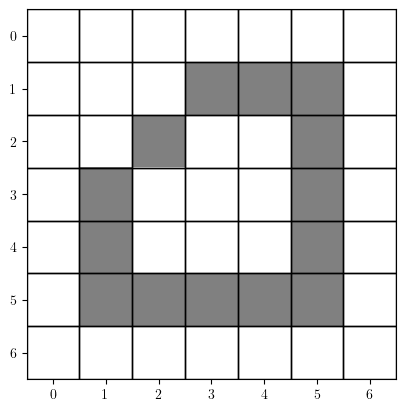

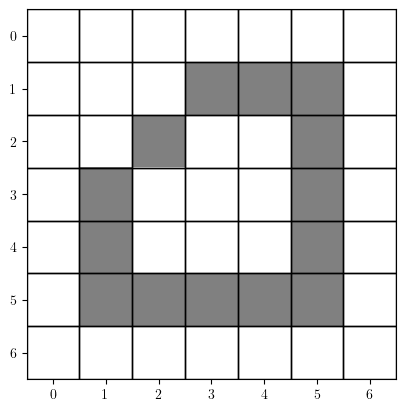

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc       
from myst_nb import glue
plt.rcParams['text.usetex'] = True

blue = [210, 210, 255]
darkblue = [0, 0, 255]
red = [128, 128, 128]
green = [230, 255, 230]
white = [255, 255, 255]

Nx, Ny = 7, 7
img = 255 * np.ones((Ny, Nx, 3)).astype(int)
img[1,3:6,:] = red
img[2:6,5,:] = red
img[5,1:5,:] = red
img[3:5,1,:] = red
img[2,2,:] = red

fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
   
plt.show()
glue("flood-fill-raster-0", fig, display=False)

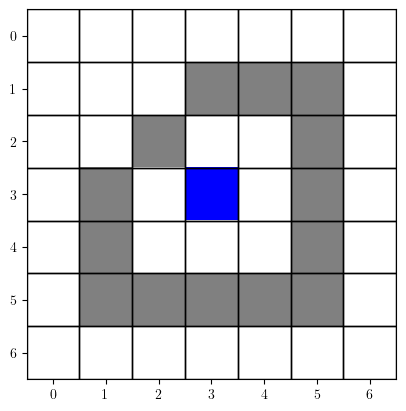

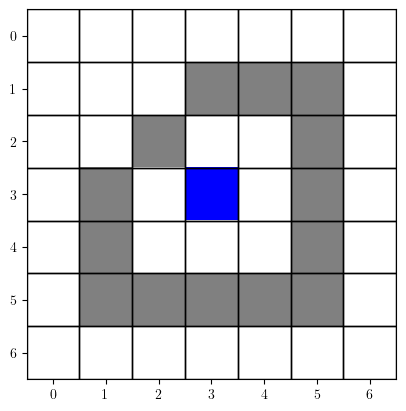

In [2]:
fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
   
img[3,3,:] = darkblue
imgplot = plt.imshow(img)
glue("flood-fill-raster-1", fig, display=False)

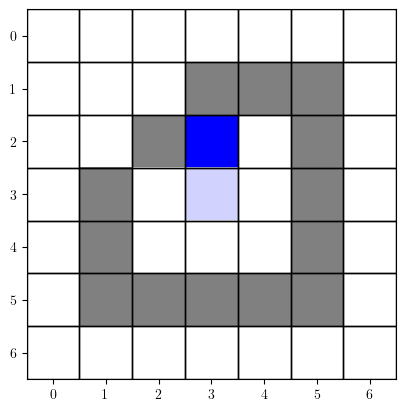

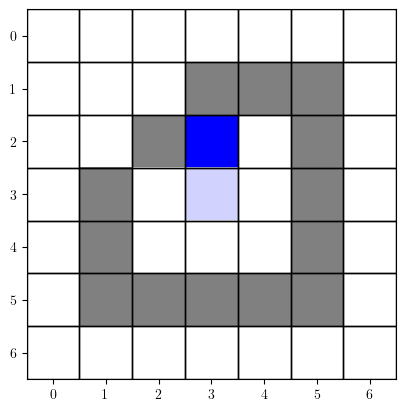

In [3]:
fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))

img[3,3,:] = blue
img[2,3,:] = darkblue
imgplot = plt.imshow(img)
glue("flood-fill-raster-2", fig, display=False)

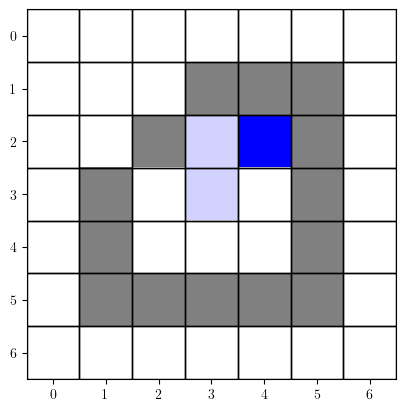

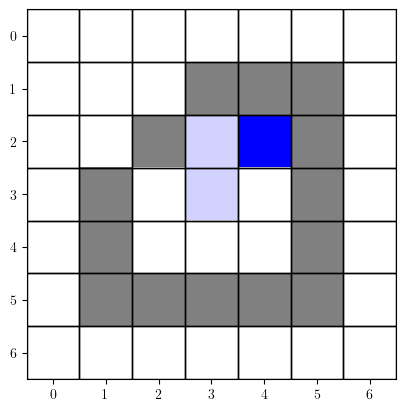

In [4]:
fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))

img[3,3,:] = blue
img[2,3,:] = blue
img[2,4,:] = darkblue
imgplot = plt.imshow(img)
glue("flood-fill-raster-3", fig, display=False)

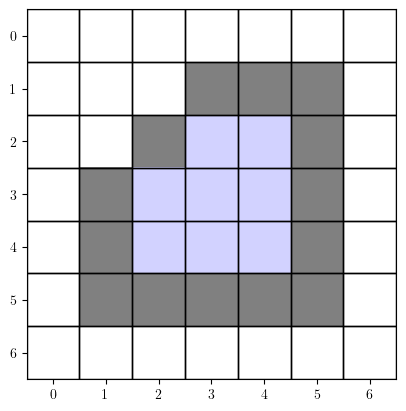

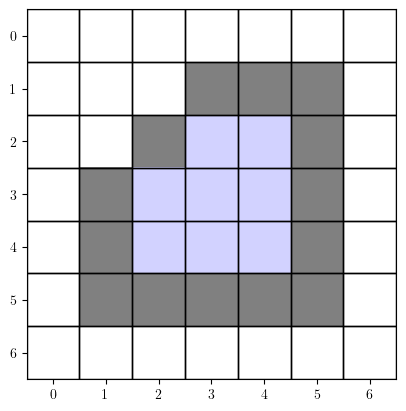

In [5]:
fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))

img[3:5,2:5,:] = blue
img[2,3:5,:] = blue
imgplot = plt.imshow(img)
glue("flood-fill-raster-4", fig, display=False)

### Use of the flood fill algorithm

Since the flood fill algorithm uses adjacent pixels to the four compass directions to spread the fill colour across a polygon is cannot spread across tight corners. This can be desirable since if the width of the outline is a single pixel then the flood fill will not leak outside of the polygon. In practice the flood fill algorithm is too computationally expensive to be used for virtual worlds and is only really used in drawing applications to provide a filling tool.

:::{glue:figure} tight-corner-raster
:figwidth: 500px

The flood fill algorithm is blocked by tight corners.
:::

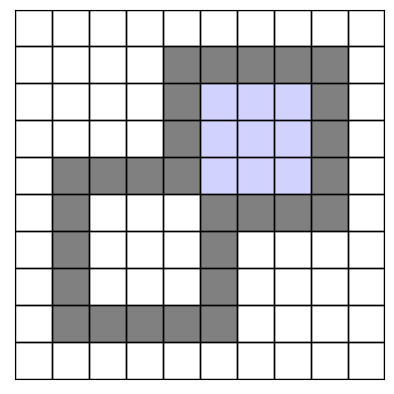

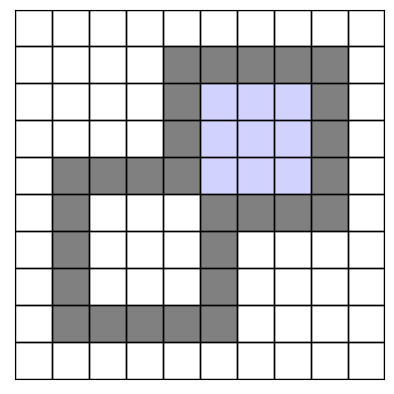

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc       
from myst_nb import glue
plt.rcParams['text.usetex'] = True

blue = [210, 210, 255]
darkblue = [0, 0, 255]
grey = [128, 128, 128]

Nx, Ny = 10, 10
img = 255 * np.ones((Ny, Nx, 3)).astype(int)
fig, ax = plt.subplots()

img[1,4:9,:] = grey
img[4,1:5,:] = grey
img[5,5:9,:] = grey
img[8,1:6,:] = grey
img[5:8,1,:] = grey
img[2:5,4,:] = grey
img[2:5,8,:] = grey
img[5:9,5,:] = grey
img[2:5,5:8] = blue

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
   
plt.xticks([])
plt.yticks([])
glue("tight-corner-raster", fig, display=False)


### The scanline algorithm

The **scanline algorithm** is a method of rendering a polygon without drawing the edges beforehand unlike the [flood fill algorithm](flood-fill-algorithm-section) that requires pixels to be plotted to form an outline. Instead of testing pixels one by one, the scanline filling algorithm loops through horizontal rows of pixels (known as a **scanline**) starting from $y=0$ and going down the raster to $y = N_y$. If the scanline intersects with an edge of the polygon the intersection points which are known as **span extrema**, are calculated, sorted into ascending order and all pixels between pairs of intersection points are filled.

:::{prf:definition} Scanline
A horizontal row of pixels.
:::

:::{prf:definition} Span extrema
A pixel where a scanline intersects with the edge of a polygons.
:::

:::{glue:figure} span-extrema-plot
:figwidth: 300px
:name: span-extrema-figure

Calculating span extrema co-ordinates.
:::

Consider {numref}`span-extrema-figure` where the co-ordinates of the span extrema on the left edge of a polygon are $(x_i, y_i)$ and $(x_{i+1}, y_{i+1})$. If $(x_i, y_i)$ are known then the next value $y_{i+1}$ is easily calculated using $y_{i+1} = y_i + 1$. The values of the $x$ span extrema co-ordinates are calculated using the <a href="https://en.wikipedia.org/wiki/Linear_equation#Slope%E2%80%93intercept_form_or_Gradient-intercept_form" target="_blank">slope intercept equation of a line</a>.

\begin{align*}
    y = \frac{\Delta y}{\Delta x} x + c,
\end{align*}

where $y$ and $x$ are the co-ordinates of a point on the line, $\Delta y / \Delta x$ is the gradient of the line and $c$ is where the line intercepts the $y$-axis. Rearranging this to make $x$ the subject gives

:::{math}
:label: span-extrema-x-equation

x = \frac{\Delta x}{\Delta y} (y - c). 
:::

To derive an expression for calculating $x_{i+1}$ we let $x_{i+1} =x $ and rearrange equation {eq}`span-extrema-x-equation` and substitute $y_{i+1} = y_i + 1$

\begin{align*}
    x_{i+1} &= \frac{\Delta x}{\Delta y} (y_{i+1} - c) \\
    &= \frac{\Delta x}{\Delta y} (y_i + 1 - c) \\
    &= \frac{\Delta x}{\Delta y} (y_i - c) + \frac{\Delta x}{\Delta y}.
\end{align*}

Since $x_i = \dfrac{\Delta x}{\Delta y} (y_i - c)$ then

\begin{align*}
    x_{i+1} &= x_i + \frac{\Delta x}{\Delta y}.
\end{align*}

So calculating the values of $y_{i+1}$ and $x_{i+1}$ is simply a matter of adding 1 to $y_i$ and $\Delta x / \Delta y$ to $x_i$. However since $\Delta x/ \Delta y$ is not an integer number this method is slower than if we were only dealing with integer numbers. We can convert the calculations for $x_{i+1}$ so that they only use integers by realising that whenever we add $\Delta x / \Delta y$ we are only adding $\Delta x$ to the numerator of the fraction, i.e., 

\begin{align*}
    x_{i+1} &= x_i + \frac{\Delta x}{\Delta y}, \\
    x_{i+2} &= x_i + \frac{\Delta x}{\Delta y} + \frac{\Delta x}{\Delta y} = x_i + \frac{\Delta x + \Delta x}{\Delta y}, \\
    & \vdots
\end{align*}

So we can add $\Delta x$ to the value of the numerator, $N$ say, and change the value of the $x$ co-ordinate by $\pm 1$ when the value fo the fraction exceeds 1 which would be when $N \geq \Delta y$. At this point $N$ is reset be subtracting $\Delta y$ from $N$. In the case where $\Delta x > n \Delta y$, i.e., we have a very shallow edge, we need to subtract $n \Delta y$ from $N$ and change $x$ by $\pm n$. 

We only want to perform the span extrema calculations on polygon edges that intersect a scanline, known as **active edges** and ignore the rest. To do this we use an **Edge Table (ET)** to store information for all edges of a polygon and an **Active Edge Table (AET)** that only contains information for the active edges. The information that is stored in ET and AET is:

- $x$ - the $x$ co-ordinate of the current span extrema
- $N$ - the value of the numerator
- $x_{step}$ - the change in the value of $x$ ($\operatorname{sign}(\Delta x)$)
- $y_{\min}$ and $y_{\max}$ - the minimum and maximum values of the $y$ endpoint co-ordinates
- $\Delta x = |x_{\min} - x_{\max}|$ and $\Delta y = |y_{\min} - y_{\max}|$

To start with we initialise ET so that it contains are edges of a polygon and AET is empty. Then as the scanline moves down the raster, any edge in ET which has $y_{\min}=y$ becomes active and is moved from ET to AET. AET is sorted into ascending order by $x$ value and we fill in the pixels between pairs of $x$ values. Any edge in AET which has $y_{\max}=y$ has become non-active so is removed from AET. We then move the scanline down one row of pixels by incrementing $y = y + 1$ and calculate the new span extrema values by adding $1/m$ to $x$ for all remaining edges in AET. When ET and AET are empty all edges have been calculated and the polygon has been drawn. 

:::{prf:algorithm} The scanline algorithm
:label: scanline-algorithm

**Inputs:** An $N_y \times N_x \times 3$ raster array $R$, two lists containing the pixel co-ordinates of the polygon vertices $X$ and $Y$ and $colour$ the colour of the polygon

**Outputs:** A raster array $R$

- ET $\gets \emptyset$ and AET $\gets \emptyset$
- For each edge of the polygon with endpoints $(x_0, y_0)$ and $(x_1, y_1)$
    - If $y_0 < y_1$ the
        - $x_{\min} \gets x_0$, $x_{\max} \gets x_1$, $y_{\min} \gets y_0$ and $y_{\max} \gets y_1$
    - Else if $y_0 > y_1$ then
        - $x_{\min} \gets x_1$, $x_{\max} \gets x_0$, $y_{\min} \gets y_1$ and $y_{\max} \gets y_0$
    - Else
        - Move to next edge (the current edge is horizontal)
    - Calculate $\Delta x \gets |x_{\min} - x_{\max}|$, $\Delta y \gets |y_{\min} - y_{\max}|$, $x_{step} \gets \operatorname{sign}(x_{\max} - x_{\min})$ and $N \gets 0$
    - Add $[ x_{\min}, N, x_{step}, \Delta x, \Delta y, y_{\min}, y_{\min} ]$ to ET
    
- $y \gets 0$
- While ET or AET are not empty
     - For each edge in ET if $y_{\min} = y$ then move edge from ET to AET
     - Sort AET by $x$ in ascending order
     - Fill pixels between every pair of $x$ co-ordinates with the colour $colour$
     - For each edge in AET
         - If $y_{\max} = y$ remove edge from AET.
         - $N \gets N + \Delta x$
         - While $N > \Delta y$ do
             - $x \gets x + x_{step}$
             - $N \gets N - \Delta y$             
     - $y \gets y + 1$
- return $R$
:::

:::::{prf:example} 
:class: seealso

Use the scanline algorithm to draw the polygon defined below

:::{glue:figure} scanline-example-0
:figwidth: 300px
:::

::::{dropdown} Solution

- Start by forming the edge table ET (since edge e2 is a horizontal edge it is not included in ET)

```
ET         x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   0   -1    2    7    1     8  ]
    e3 : [ 7   0    1    1    5    3     8  ]
    e4 : [ 7   0   -1    2    3    3     6  ]
    e5 : [ 3   0    1    2    5    1     6  ]
```

- Starting with $y=0$ none of the edges in ET have $y_{\min} = 0$ so increment $y=1$
- Edges e1 and e5 have $y_{\min} = 1$ so are moved to the AET

```
ET         x   N  xstep  Dx   Dy  ymin  ymax
    e3 : [ 7   0    1    1    5    3     8  ]
    e4 : [ 7   0   -1    2    3    3     6  ]
    
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   0   -1    2    7    1     8  ]
    e5 : [ 3   0    1    2    5    1     6  ]
```

- None of the edges in AET have $y_{\max}=1$ and it is already sorted by $x$ value so fill pixel $(3, 1)$

:::{glue:figure} scanline-example-1
:figwidth: 300px
:::

- Add $\Delta x$ to $N$ for all edges in AET 
- Increment $y = 1 + 1 = 2$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   2   -1    2    7    1     8  ]
    e5 : [ 3   2    1    2    5    1     6  ]
```

- None of the edges in ET have $y_{\min} = 2$ and so fill pixel $(3, 2)$

:::{glue:figure} scanline-example-2
:figwidth: 300px
:::

- Add $\Delta x$ to $N$ for all edges in AET 
- Increment $y = 2 + 1 = 3$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   4   -1    2    7    1     8  ]
    e5 : [ 3   4    1    2    5    1     6  ]
```

- Edges e3 and e4 in ET both have $y_{\min} = 3$ so are moved to AET
- ET is now empty and ignored from now on

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   4   -1    2    7    1     8  ]
    e5 : [ 3   4    1    2    5    1     6  ]
    e3 : [ 7   0    1    1    5    3     8  ]
    e4 : [ 7   0   -1    2    3    3     6  ]
```

- Fill pixels $(3, 3)$ and $(7, 3)$

:::{glue:figure} scanline-example-3
:figwidth: 300px
:::

- We add $\Delta x$ to $N$ for all edges in AET

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   6   -1    2    7    1     8  ]
    e5 : [ 3   6    1    2    5    1     6  ]
    e3 : [ 7   1    1    1    5    3     8  ]
    e4 : [ 7   2   -1    2    3    3     6  ]
```

- Edge e5 has $N = 6 \geq \Delta y = 7$ so subtract $\Delta y$ from $N$ to give $N = 6 - 5 = 1$ which is less than $\Delta y$ and add $x_{step} = 1$ to $x$ to give $x = 3 + 1 = 4$
- Increment $y = 3 + 1 = 4$. 

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   6   -1    2    7    1     8  ]
    e5 : [ 4   1    1    2    5    1     6  ]
    e3 : [ 7   1    1    1    5    3     8  ]
    e4 : [ 7   2   -1    2    3    3     6  ]
```

- We fill pixels $(3, 4)$, $(4, 4)$ and $(7, 4)$

:::{glue:figure} scanline-example-4
:figwidth: 300px
:::

- Add $\Delta x$ to $N$ for all edges in AET

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 3   8   -1    2    7    1     8  ]
    e5 : [ 4   3    1    2    5    1     6  ]
    e3 : [ 7   2    1    1    5    3     8  ]
    e4 : [ 7   4   -1    2    3    3     6  ]
```

- Edge e1 has $N = 8 \geq \Delta y = 7$ so subtract $\Delta y$ from $N$ to give $N = 8 - 7 = 1$ which is less than $\Delta y$ and add $x_{step} = -1$ to $x$ to give $x = 3 - 1 = 2$
- Edge e4 has $N=4 \geq \Delta y = 3$ so subtract $\Delta y$ from $N$ to give $N = 4 - 3 = 1$ which is less than $\Delta y$ and add $x_{step} = -1$ to $x$ to give $x = 7 - 1 = 6$
- Increment $y = 4 + 1 = 5$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 2   1   -1    2    7    1     8  ]
    e5 : [ 4   3    1    2    5    1     6  ]
    e3 : [ 7   2    1    1    5    3     8  ]
    e4 : [ 6   1   -1    2    3    3     6  ]
```

- AET is sorted by the $x$ values

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 2   1   -1    2    7    1     8  ]
    e5 : [ 4   3    1    2    5    1     6  ]
    e4 : [ 6   1   -1    2    3    3     6  ]
    e3 : [ 7   2    1    1    5    3     8  ]
```

- Fill pixels $(2, 5)$ to $(4, 5)$, $(6, 5)$ and $(7,5)$

:::{glue:figure} scanline-example-5
:figwidth: 300px
:::

- Add $\Delta x$ to $N$ for all edges in AET

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 2   3   -1    2    7    1     8  ]
    e5 : [ 4   5    1    2    5    1     6  ]
    e4 : [ 6   3   -1    2    3    3     6  ]
    e3 : [ 7   3    1    1    5    3     8  ]
```

- Edge e5 has $N = 5 \geq \Delta y = 5$ so subtract $\Delta y$ from $N$ to give $N = 5 - 5 = 0$ which is less than $\Delta y$ and add $x_{step} = 1$ to $x$ to give $x = 4 + 1 = 5$
- Edge e4 has $N = 3 \geq \Delta y = 3$ so subtract $\Delta y$ from $N$ to give $N = 3 - 3 = 0$ which is less than $\Delta y$ and add $x_{step} = -1$ to $x$ to give $x = 6 - 1 = 5$
- Increment $y = 4 + 1 = 6$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 2   3   -1    2    7    1     8  ]
    e5 : [ 5   0    1    2    5    1     6  ]
    e4 : [ 5   0   -1    2    3    3     6  ]
    e3 : [ 7   3    1    1    5    3     8  ]
```

- Fill pixels $(2, 6)$ to $(5, 6)$ and $(5, 6)$ to $(7, 6)$

:::{glue:figure} scanline-example-6
:figwidth: 300px
:::

- Edges e5 and e4 have $y_{\max} = y$ so are removed from AET
- Add $\Delta x$ to $N$ for all edges in AET
- Increment $y = 6 + 1 = 7$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 2   5   -1    2    7    1     8  ]
    e3 : [ 7   4    1    1    5    3     8  ]
```

- Fill pixels $(2, 7)$ to $(7, 7)$

:::{glue:figure} scanline-example-7
:figwidth: 300px
:::

- Add $\Delta x$ to $N$ for all edges in AET
- Increment $y = 7 + 1 = 8$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 2   7   -1    2    7    1     8  ]
    e3 : [ 7   5    1    1    5    3     8  ]
```

- Edge e1 has $N = 7 \geq \Delta y = 7$ so subtract $\Delta y$ from $N$ to give $N = 7 - 7 = 0$ which is less than $\Delta y$ so add $x_{step} = -1$ to $x$ to give $x = 2 - 1 = 1$
- Edge e3 has $N = 5 \geq \Delta y = 5$ so subtract $\Delta y$ from $N$ to give $N = 5 - 5 = 0$ which is less than $\Delta y$ so add $x_{step} = 1$ to $x$ to give $x = 7 + 1 = 8$
- Increment $y = 7 + 1 = 8$

```
AET        x   N  xstep  Dx   Dy  ymin  ymax
    e1 : [ 1   0   -1    2    7    1     8  ]
    e3 : [ 8   0    1    1    5    3     8  ]
```

- Fill pixels $(1, 8)$ to $(8, 8)$.

:::{glue:figure} scanline-example-8
:figwidth: 300px
:::

- Both edges e1 and e3 have $y_{\max} = 8$ to are removed from AET
- AET is now empty so the algorithm terminates
::::

:::::

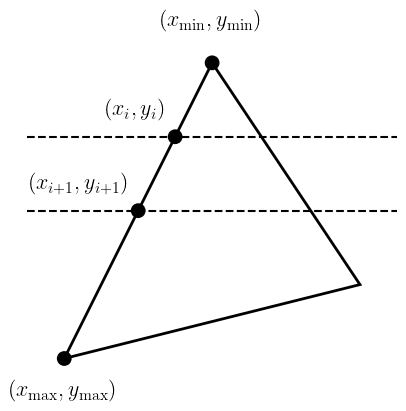

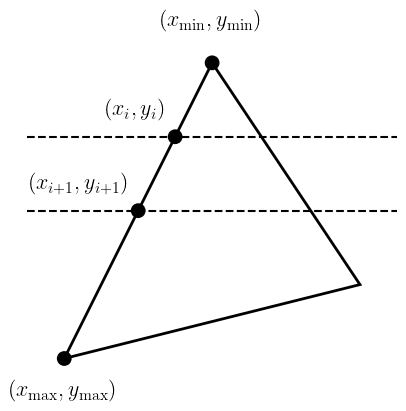

In [7]:
import numpy as np
import matplotlib.pyplot as plt     
from myst_nb import glue
plt.rcParams['text.usetex'] = True

  
def pixelcoordinates(x, y, Nx, Ny):
    x = [int(x * Nx) for x in x]
    y = [int((1 - y) * Ny) for y in y]
    return x, y


blue = [210, 210, 255]
darkblue = [0, 0, 255]
grey = [128, 128, 128]

Nx, Ny = 5, 5
x = [0.1, 0.9, 0.5]
y = [0.1, 0.3, 0.8]
x, y = pixelcoordinates(x, y, Nx, Ny)
        
img = 255 * np.ones((Nx, Ny, 3)).astype(int)

fig, ax = plt.subplots()

imgplot = plt.imshow(img)
# for i in range(Nx):
#     for j in range(Ny):
#         ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
plt.axhline(y = 1, color = 'k', linestyle = '--')        
plt.axhline(y = 2, color = 'k', linestyle = '--')        

ax.add_patch(plt.Circle((1.5, 1), 0.1, fc="k"))
ax.add_patch(plt.Circle((1, 2), 0.1, fc="k"))
ax.add_patch(plt.Circle((2, 0), 0.1, fc="k"))
ax.add_patch(plt.Circle((0, 4), 0.1, fc="k"))
text1 = plt.text(1.5-0.1, 0.7, s="$(x_i, y_i)$", fontsize=16,ha="right")
text2 = plt.text(1.0-0.1, 1.7, s="$(x_{i+1}, y_{i+1})$", fontsize=16,ha="right")
text3 = plt.text(2.0, -0.5, s="$(x_{\min}, y_{\min})$", fontsize=16,ha="center")
text4 = plt.text(0.0, 4.5, s="$(x_{\max}, y_{\max})$", fontsize=16,ha="center")
# text5 = plt.text(4, 1, s="scanline", fontsize=16)
text1.set_bbox(dict(facecolor='white', alpha=1, ec="none"))
text2.set_bbox(dict(facecolor='white', alpha=1, ec="none"))
text3.set_bbox(dict(facecolor='white', alpha=1, ec="none"))
text4.set_bbox(dict(facecolor='white', alpha=1, ec="none"))
# text5.set_bbox(dict(facecolor='white', alpha=1, ec="none"))
        
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.axis("off")
plt.fill(x, y, fill=False,lw=2)
glue("span-extrema-plot", fig, display=False)

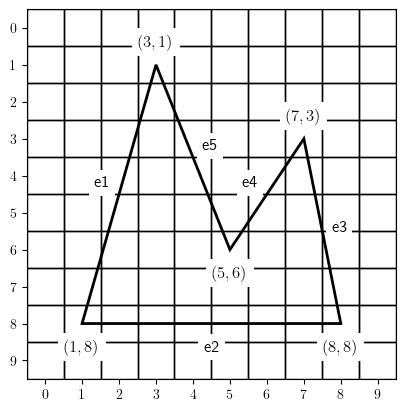

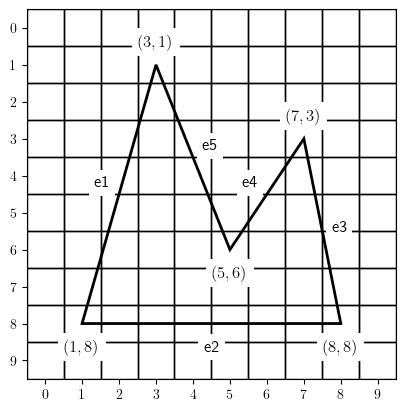

In [8]:
import numpy as np
import matplotlib.pyplot as plt     
from myst_nb import glue
plt.rcParams['text.usetex'] = True

def pixelcoordinates(X, Y, Nx, Ny):
    X = [int(x * Nx) for x in X]
    Y = [int((1 - y) * Nx) for y in Y]
    return X, Y

blue = [210, 210, 255]
darkblue = [0, 0, 255]
greY = [128, 128, 128]

Nx, Ny = 10, 10
X = [0.1, 0.8, 0.7, 0.5, 0.3]
Y = [0.2, 0.2, 0.7, 0.4, 0.8]
X, Y = pixelcoordinates(X, Y, Nx, Nx)

img = 255 * np.ones((Nx, Nx, 3)).astype(int)

fig, ax = plt.subplots()

imgplot = plt.imshow(img)
t = [plt.text(X[0], Y[0]+0.75, s="$(1,8)$", ha="center", fontsize=12)]
t.append(plt.text(X[1], Y[1]+0.75, s="$(8,8)$", ha="center", fontsize=12))
t.append(plt.text(X[2], Y[2]-0.5, s="$(7,3)$", ha="center", fontsize=12))
t.append(plt.text(X[3], Y[3]+0.75, s="$(5, 6)$", ha="center", fontsize=12))
t.append(plt.text(X[4], Y[4]-0.5, s="$(3,1)$", ha="center", fontsize=12))
t.append(plt.text(0.5 * (X[0] + X[1]), 0.5 * (Y[0] + Y[1])+0.75, s="e2", fontsize=12, ha="center"))
t.append(plt.text(0.5 * (X[1] + X[2]) + 0.25, 0.5 * (Y[1] + Y[2]), s="e3", fontsize=12, ha="left"))
t.append(plt.text(0.5 * (X[2] + X[3]) - 0.25, 0.5 * (Y[2] + Y[3]) - 0.2, s="e4", fontsize=12, ha="right"))
t.append(plt.text(0.5 * (X[3] + X[4]) + 0.25, 0.5 * (Y[3] + Y[4]) - 0.2, s="e5", fontsize=12, ha="left"))
t.append(plt.text(0.5 * (X[4] + X[0]) - 0.25, 0.5 * (Y[4] + Y[0]) - 0.2, s="e1", fontsize=12, ha="right"))

for box in t:
    box.set_bbox(dict(facecolor='white', alpha=1, ec="none"))
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
plt.xticks(range(Nx))
plt.yticks(range(Ny))
plt.fill(X, Y, fill=False,lw=2)
glue("scanline-example-0", fig, display=False)

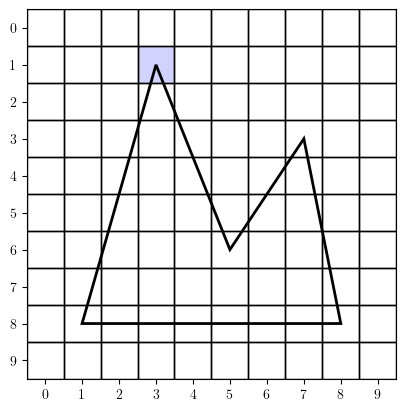

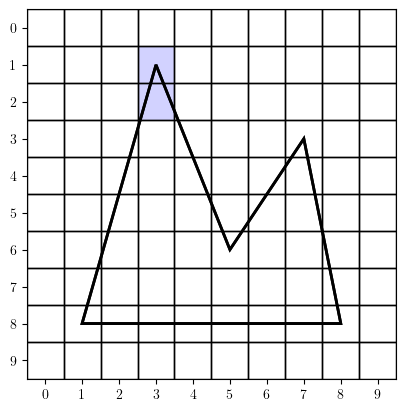

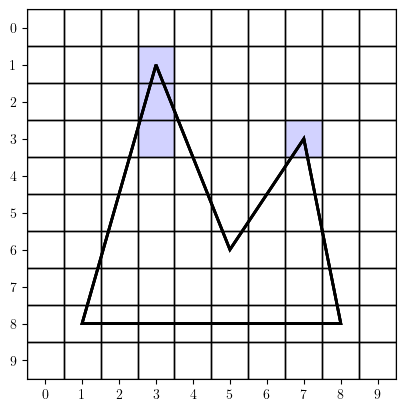

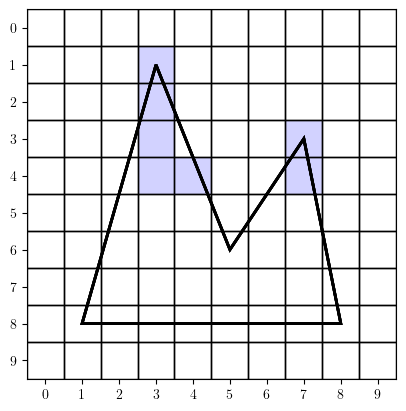

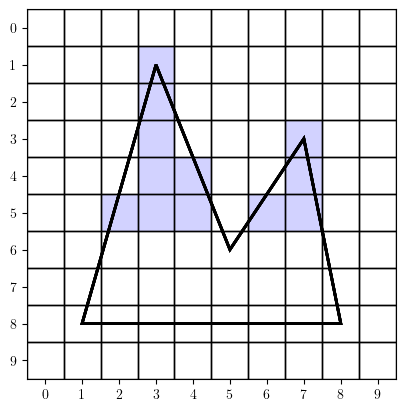

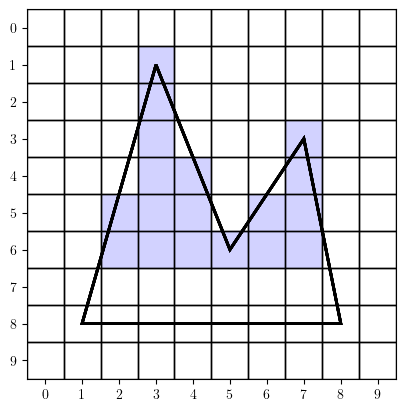

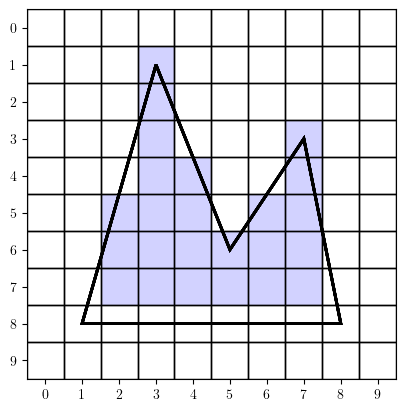

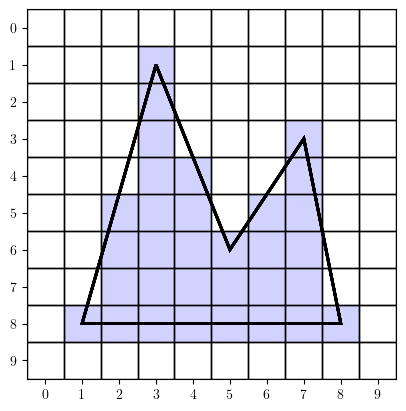

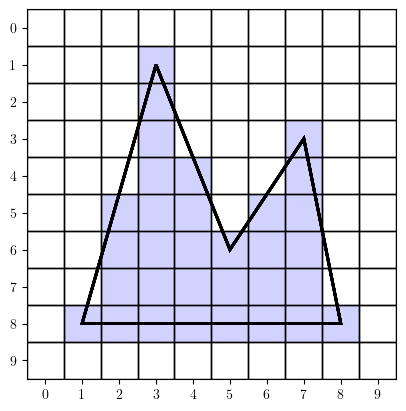

In [9]:
def drawpolygon(R, X, Y, colour):

    # Generate edge table
    n = len(X)
    ET = []
    j = n - 1
    for i in range(n):
        if Y[i] < Y[j]:
            imin, imax = i, j
        elif Y[i] > Y[j]:
            imin, imax = j, i
        else:
            j = i
            continue
            
        dx, dy = X[imin] - X[imax], Y[imin] - Y[imax]
        if dx > 0:
            xstep = -1
        elif dx < 0:
            xstep = 1
            
        ET.append([X[imin], Y[imin], Y[imax], xstep, abs(dx), abs(dy), 0])
        j = i

    # Loop through scanlines
    y = min(Y)
    AET = []
    n = 1
    while len(ET) > 0 or len(AET) > 0:
        
        # Move edges from ET to AET whose ymin = y
        i = 0
        while i < len(ET):
            if ET[i][1] == y:
                AET.append(ET.pop(i))
            else:
                i += 1
        
        # Sort AET by x value
        AET.sort()
        
        # Fill scanline
        i = 0
        while i < len(AET) - 1:
            R[y,AET[i][0]:AET[i+1][0]+1,:] = colour
            i += 2
                
        for edge in AET.copy():
            # Remove edges from AET whose ymax = y
            if edge[2] == y:
                AET.remove(edge)

            # Update N and x
            edge[6] += edge[4]
            while edge[6] >= edge[5]:
                edge[6] -= edge[5]
                edge[0] += edge[3]
                
        y += 1
        
        plt.imshow(R)
        plt.xticks(range(Nx))
        plt.yticks(range(Ny))
        plt.fill(X, Y, fill=False,lw=2)
        glue(f"scanline-example-{n}", fig, display=False)
        n += 1
              
    return R 
    

img = 255 * np.ones((Nx, Ny, 3)).astype(int)
fig, ax = plt.subplots()
imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))

img = drawpolygon(img, X, Y, blue)        

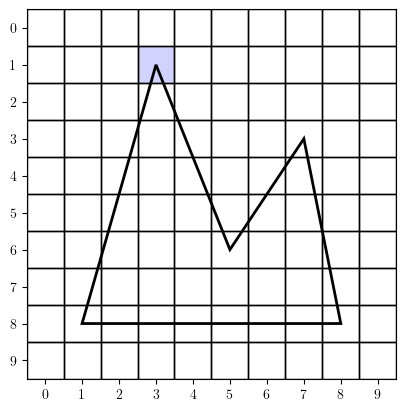

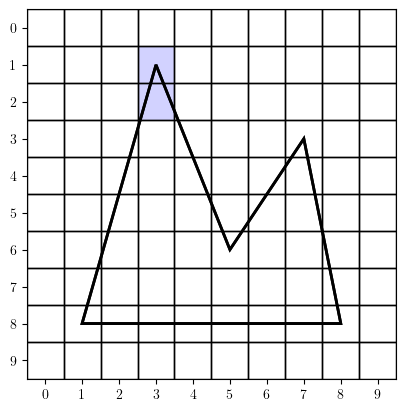

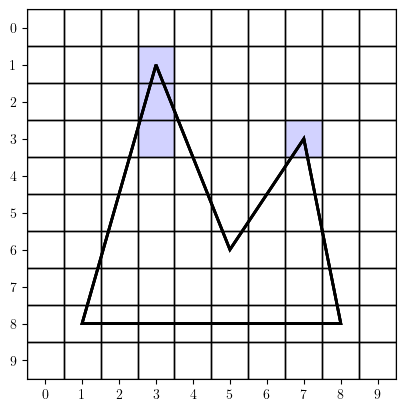

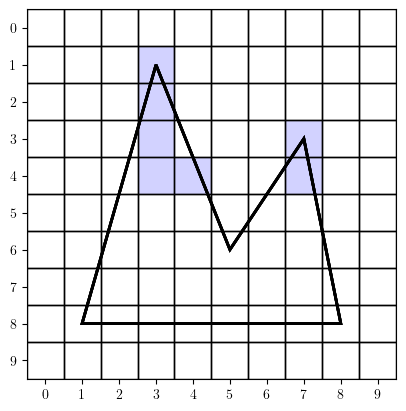

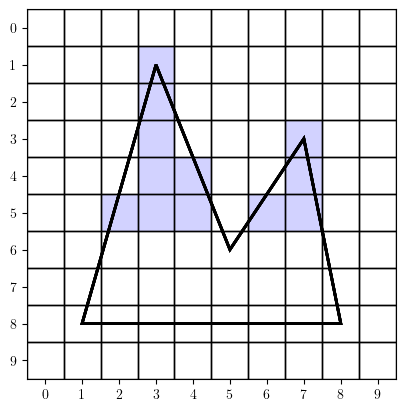

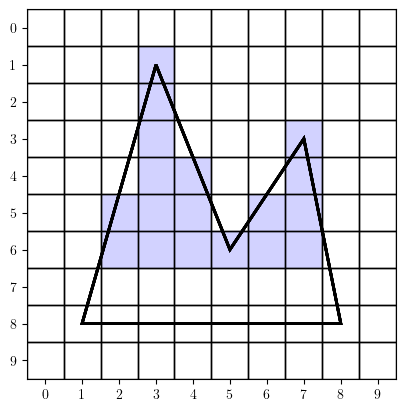

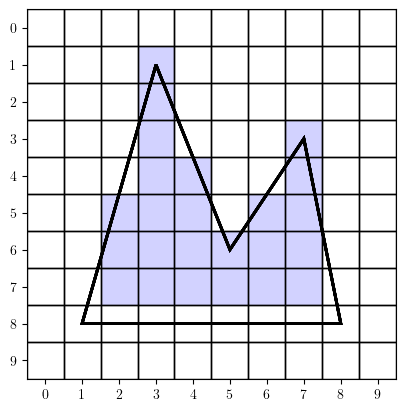

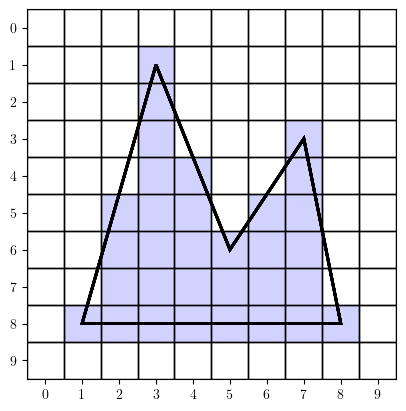

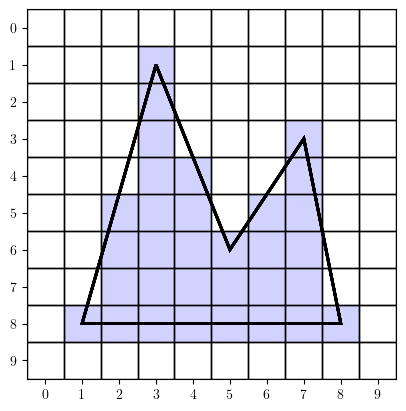

In [10]:
def drawpolygon(R, X, Y, colour):
    
    # Generate edge table
    n = len(X)
    ET = []
    j = n - 1
    for i in range(n):
        if Y[i] < Y[j]:
            imin, imax = i, j
        elif Y[i] > Y[j]:
            imin, imax = j, i
        else:
            j = i
            continue
            
        dx, dy = abs(X[imin] - X[imax]), abs(Y[imin] - Y[imax])
        if X[imin] > X[imax]:
            xstep = -1
        else:
            xstep = 1
        
        edge = {'x' : X[imin], 'N' : 0, 'dx' : abs(dx), 'dy' : abs(dy), 
                'ymin' : Y[imin], 'ymax' : Y[imax], 'xstep' : xstep}
        ET.append(edge)
        j = i


    # Loop through scanlines
    y = min(Y)
    AET = []
    n = 1
    while len(ET) > 0 or len(AET) > 0:
        
        # Move edges from ET to AET whose ymin = y
        i = 0
        while i < len(ET):
            if ET[i]["ymin"] == y:
                AET.append(ET.pop(i))
            else:
                i += 1
        
        # Sort AET by x value
        AET = sorted(AET, key=lambda d: d['x']) 
        
        # Fill scanline
        i = 0
        while i < len(AET) - 1:
            R[y,AET[i]['x']:AET[i+1]['x']+1,:] = colour
            i += 2
                
        for edge in AET.copy():
            # Remove edges from AET whose ymax = y
            if edge['ymax'] == y:
                AET.remove(edge)

            # Update N and x
            edge['N'] += edge['dx']
            while edge['N'] >= edge['dy']:
                edge['N'] -= edge['dy']
                edge['x'] += edge['xstep']

        y += 1
        
        
        plt.imshow(R)
        plt.xticks(range(Nx))
        plt.yticks(range(Ny))
        plt.fill(X, Y, fill=False,lw=2)
        glue(f'scanline-example-{n}', fig, display=False)
        n += 1
              
    return R 
    

img = 255 * np.ones((Nx, Ny, 3)).astype(int)
fig, ax = plt.subplots()
imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec='k', fill=False))

img = drawpolygon(img, X, Y, blue)        

In [11]:
edge = {"a" : 1, "b" : 2}
print(edge.a)

AttributeError: 'dict' object has no attribute 'a'